# Research question 2: does grounding reduce unsupported claims

Every value the Insight system stores is supposed to be backed by evidence (the conversation lines that support it). The two LLM pipelines differ in exactly one thing: P2 only sees the five retrieved lines per field and must cite them, P3 sees the whole conversation. Same model, same prompt, same schema.

Here the unsupported-claim rate (UCR) is measured of both pipelines: how often a pipeline asserts a value without a single citation that survives the grounding filter. P1 is out of scope, a classifier can not cite.

The numbers come from `evaluation/rq2/out/` (produced by `evaluation/run.py`).

In [5]:
# The repository root is the first parent directory holding docker-compose.yml
import csv
import json
from pathlib import Path

REPO = Path.cwd().resolve()
while not REPO.joinpath("docker-compose.yml").exists():
  REPO = REPO.parent

OUT = REPO.joinpath("evaluation", "rq2", "out")
print("reading from:", OUT)

reading from: /home/amed/uni/insight/evaluation/rq2/out


## The scores

Why this output: these counts decide both pre-committed criteria, the grounding claim of the project stands or falls here.

The vocabulary, pinned once:
- a value is **claim-bearing** when it asserts something (not `unknown`, not `none`)
- **supported** = claim-bearing with at least one surviving citation
- **uncited** = the model cited nothing; **invalid** = everything it cited was dropped by the grounding filter (lines it was never shown)
- **ucr** = (uncited + invalid) / claims, lower is better
- **validity** = share of fields whose first answer was already a legal schema value (an off-schema answer is coerced to unknown and counts against this)

In [6]:
scores_file = OUT.joinpath("scores.json")
if not scores_file.exists():
  print("no rq2 scores yet; run evaluation/run.py first")
else:
  scores = json.loads(scores_file.read_text())
  print(f"{'pipeline':<9} {'scope':<12} {'claims':<7} {'supported':<10} {'uncited':<8} {'invalid':<8} {'ucr':<7} validity")
  for pipeline in ("p2", "p3"):
    for scope, t in scores[pipeline].items():
      ucr = f"{t['ucr']:.3f}" if t["ucr"] is not None else "-"
      validity = f"{t['validity']:.3f}" if t["validity"] is not None else "-"
      print(f"{pipeline:<9} {scope:<12} {t['claim_bearing']:<7} {t['supported']:<10} "
            f"{t['uncited']:<8} {t['invalid_cited']:<8} {ucr:<7} {validity}")
  print("\npre-committed criteria, judged:")
  print(json.dumps(scores["criteria"], indent=1))

pipeline  scope        claims  supported  uncited  invalid  ucr     validity
p2        abcd-text    419     419        0        0        0.000   1.000
p2        hvb-audio    79      79         0        0        0.000   1.000
p2        maia-text    348     348        0        0        0.000   1.000
p2        overall      846     846        0        0        0.000   1.000
p3        abcd-text    668     667        0        1        0.001   1.000
p3        hvb-audio    154     154        0        0        0.000   1.000
p3        maia-text    405     404        0        1        0.002   1.000
p3        overall      1227    1225       0        2        0.002   1.000

pre-committed criteria, judged:
{
 "ucr_p2_lt_p3": {
  "p2": 0.0,
  "p3": 0.0016299918500407497,
  "met": true
 },
 "validity_ge_95": {
  "p2": {
   "validity": 1.0,
   "met": true
  },
  "p3": {
   "validity": 1.0,
   "met": true
  }
 }
}


## The picture

Why this output: the rq2 verdict is one visual comparison, the p2 bar must sit below the p3 bar in every scope. The rates are near zero, so every bar carries its value.

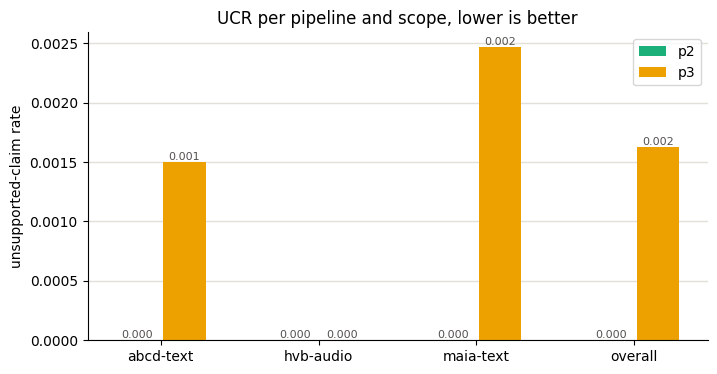

In [7]:
import matplotlib.pyplot as plt

COLORS = {"p2": "#1baf7a", "p3": "#eda100"}

if not scores_file.exists():
  print("no rq2 scores yet; run evaluation/run.py first")
else:
  scores = json.loads(scores_file.read_text())
  scopes = list(scores["p2"])

  fig, ax = plt.subplots(figsize=(8, 4))
  for offset, pipeline in enumerate(("p2", "p3")):
    xs = []
    ys = []
    for index, scope in enumerate(scopes):
      t = scores[pipeline][scope]
      if t["ucr"] is not None:
        xs.append(index + (offset - 0.5) * 0.3)
        ys.append(t["ucr"])
    ax.bar(xs, ys, width=0.27, color=COLORS[pipeline], label=pipeline)
    # The rates are near zero, the bars need their values written out
    for x, y in zip(xs, ys):
      ax.text(x, y, f"{y:.3f}", ha="center", va="bottom", fontsize=8, color="#52514e")

  ax.set_xticks(range(len(scopes)))
  ax.set_xticklabels(scopes)
  ax.set_ylim(bottom=0)
  ax.set_ylabel("unsupported-claim rate")
  ax.set_title("UCR per pipeline and scope, lower is better")
  ax.legend()
  ax.grid(axis="y", color="#e1e0d9", linewidth=1)
  ax.set_axisbelow(True)
  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)
  plt.show()

## An unsupported claim, concretely

The first stored claim without a surviving citation: the pipeline asserted a value and could not point at a line that backs it. This is the failure mode the whole grounding design exists to reduce.

In [8]:
results_file = OUT.joinpath("results.csv")
rows = list(csv.DictReader(open(results_file))) if results_file.exists() else []
unsupported = [r for r in rows if r["claim_bearing"] == "1" and r["supported"] == "0"]
if not unsupported:
  print("no rq2 results yet, or every claim was supported")
else:
  example = unsupported[0]
  print(f"{example['pipeline']} on {example['record']} ({example['batch']}):")
  print(f"  {example['field']} = {example['value']!r}")
  print(f"  surviving citations: {example['citations']}, dropped by the filter: {example['dropped']}")
  print(f"\n{len(unsupported)} unsupported claims in total, per pipeline:")
  for pipeline in ("p2", "p3"):
    print(f"  {pipeline}: {sum(1 for r in unsupported if r['pipeline'] == pipeline)}")

p3 on abcd-3034 (abcd-text):
  intent = 'information_request'
  surviving citations: 0, dropped by the filter: 2

2 unsupported claims in total, per pipeline:
  p2: 0
  p3: 2


## What to conclude

If `ucr_p2_lt_p3.met` is true, restricting the model to retrieved evidence reduced unsupported values under matched conditions, the central grounding claim of the project. Read UCR together with rq1's accuracy: a pipeline can buy a low UCR by abstaining often, which shows up there as lower coverage. The machine-readable numbers live in `evaluation/rq2/out/scores.json` and `results.csv`.